___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright Pierian Data</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# RNN Exercise

**TASK: IMPORT THE BASIC LIBRARIES YOU THINK YOU WILL USE**

## Data

Info about this data set: https://fred.stlouisfed.org/series/IPN31152N


Units:  Index 2012=100, Not Seasonally Adjusted

Frequency:  Monthly

The industrial production (IP) index measures the real output of all relevant establishments located in the United States, regardless of their ownership, but not those located in U.S. territories.

NAICS = 31152

Source Code: IP.N31152.N

Suggested Citation:
Board of Governors of the Federal Reserve System (US), Industrial Production: Nondurable Goods: Ice cream and frozen dessert [IPN31152N], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/IPN31152N, November 16, 2019.

# Project Tasks

**TASK: Read in the data set "Frozen_Dessert_Production.csv" from the Data folder. Figure out how to set the date to a datetime index columns**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

import seaborn as sns
sns.set_style("darkgrid")

%config InlineBackened.format_figure = "SVG"

In [2]:
%pwd

'c:\\Users\\ahmad\\Desktop\\Python_Files\\Jose Portilla\\TensorFlow\\TF_2_Notebooks_and_Data\\05-RNNs'

In [3]:
# CODE HERE
df = pd.read_csv('../DATA/Frozen_Dessert_Production.csv' , index_col="DATE", parse_dates=True )
df

,IPN31152N
DATE,
1972-01-01,59.9622
1972-02-01,67.0605
1972-03-01,74.2350
1972-04-01,78.1120
1972-05-01,84.7636
...,...
2019-05-01,114.5613
2019-06-01,124.9605
2019-07-01,110.2632


**Task: Change the column name to Production**

In [4]:
#CODE HERE
df.columns = ["Production"]
df

,Production
DATE,
1972-01-01,59.9622
1972-02-01,67.0605
1972-03-01,74.2350
1972-04-01,78.1120
1972-05-01,84.7636
...,...
2019-05-01,114.5613
2019-06-01,124.9605
2019-07-01,110.2632


**TASK: Plot out the time series**

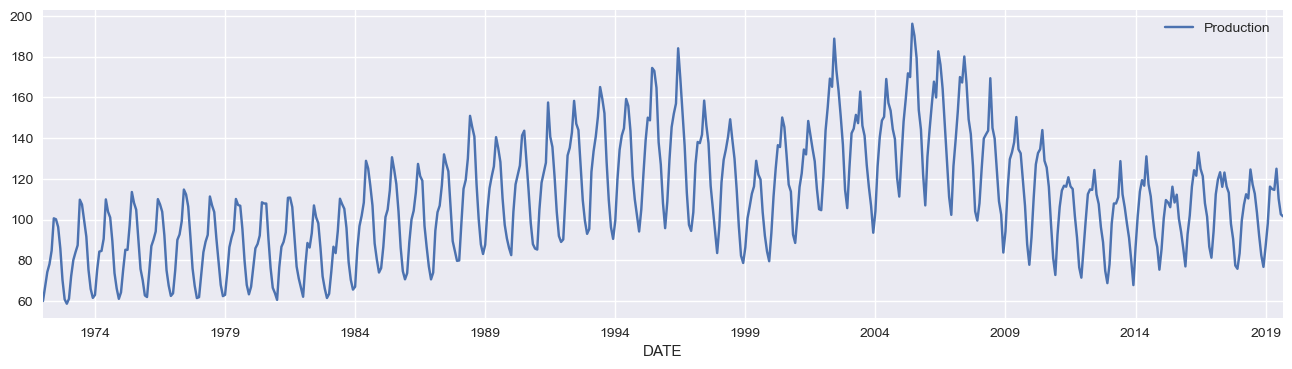

In [6]:
#CODE HERE
df.plot(figsize=(16,4), legend=True);

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

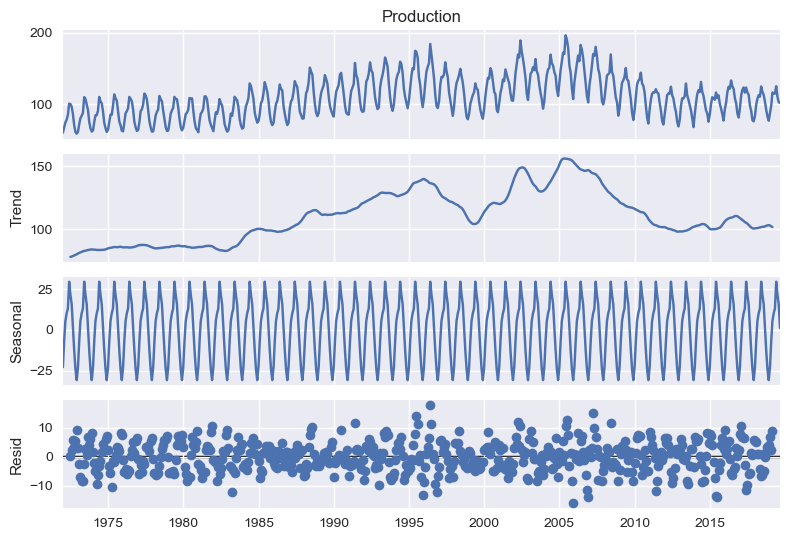

In [8]:
result = seasonal_decompose(df["Production"], model = "additive")
result.plot()
plt.show()

## Train Test Split

**TASK: Figure out the length of the data set**

In [9]:
#CODE HERE
len(df)

573

**TASK: Split the data into a train/test split where the test set is the last 24 months of data.**

In [10]:
#CODE HERE
test_size = 25
test_index = len(df) - test_size

In [11]:
train = df.iloc[:test_index]
test = df.iloc[test_index:]

In [12]:
len(test)

25

## Scale Data

**TASK: Use a MinMaxScaler to scale the train and test sets into scaled versions.**

In [13]:
# CODE HERE
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [14]:
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

In [15]:
scaled_train.shape , scaled_test.shape

((548, 1), (25, 1))

# Time Series Generator

**TASK: Create a TimeSeriesGenerator object based off the scaled_train data. The batch length is up to you, but at a minimum it should be at least 18 to capture a full year seasonality.**

In [16]:
import tensorflow
import keras

In [17]:
#CODE HERE
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [18]:
length = 18
n_features = 1
generator = TimeseriesGenerator(scaled_train , scaled_train , length=length , batch_size = 1)

### Create the Model

**TASK: Create a Keras Sequential Model with as many LSTM units you want and a final Dense Layer.**

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , LSTM

In [20]:
model = Sequential()
model.add(LSTM(100,activation='relu', input_shape = (length , n_features)))
model.add(Dense(1))
model.compile(optimizer = 'adam', loss = 'mse')

c:\Users\ahmad\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

**TASK: Create a generator for the scaled test/validation set. NOTE: Double check that your batch length makes sense for the size of the test set as mentioned in the RNN Time Series video.**

In [22]:
# CODE HERE
validation_generator = TimeseriesGenerator(scaled_test , scaled_test , length=length , batch_size=1)
validation_generator

**TASK: Create an EarlyStopping callback based on val_loss.**

In [23]:
#CODE HERE
from tensorflow.keras.callbacks import EarlyStopping

In [24]:
early_stop = EarlyStopping(monitor='val_loss', patience = 2)

**TASK: Fit the model to the generator, let the EarlyStopping dictate the amount of epochs, so feel free to set the parameter high.**

In [25]:
# CODE HERE
model.fit(generator,
          epochs = 20,
          validation_data = validation_generator,
          callbacks = [early_stop])

Epoch 1/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0283 - val_loss: 0.0102
Epoch 2/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0123 - val_loss: 0.0059
Epoch 3/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0063 - val_loss: 0.0024
Epoch 4/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0043 - val_loss: 0.0023
Epoch 5/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0034 - val_loss: 0.0027
Epoch 6/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0036 - val_loss: 0.0033


**TASK: Plot the history of the loss that occured during training.**

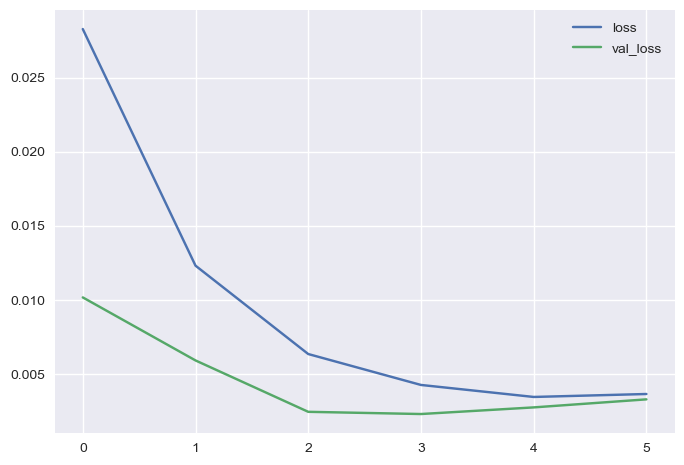

In [26]:
# CODE HERE
loss = pd.DataFrame(model.history.history)
loss.plot()
plt.show()

## Evaluate on Test Data

**TASK: Forecast predictions for your test data range (the last 12 months of the entire dataset). Remember to inverse your scaling transformations. Your final result should be a DataFrame with two columns, the true test values and the predictions.**

In [36]:
# CODE HERE

In [27]:
test_predictions = []

first_eval_batch = scaled_train[-length:]
current_batch = first_eval_batch.reshape((1,length, n_features))

for i in range(len(test)):
    current_pred = model.predict(current_batch)[0]
    test_predictions.append(current_pred)
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]], axis = 1)
    


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [33]:
true_predictions = scaler.inverse_transform(test_predictions)
test["Model_Predictions"] = true_predictions

In [36]:
test

,Production,Model_Predictions
DATE,,
2017-09-01,97.9125,108.833511
2017-10-01,90.4732,100.990258
2017-11-01,77.4378,92.428939
2017-12-01,75.8118,86.256522
2018-01-01,83.4343,90.819430
2018-02-01,99.4899,101.822986
2018-03-01,107.3152,111.498883
2018-04-01,112.4309,118.853425
2018-05-01,110.3544,124.075968


**TASK: Plot your predictions versus the True test values. (Your plot may look different than ours).**

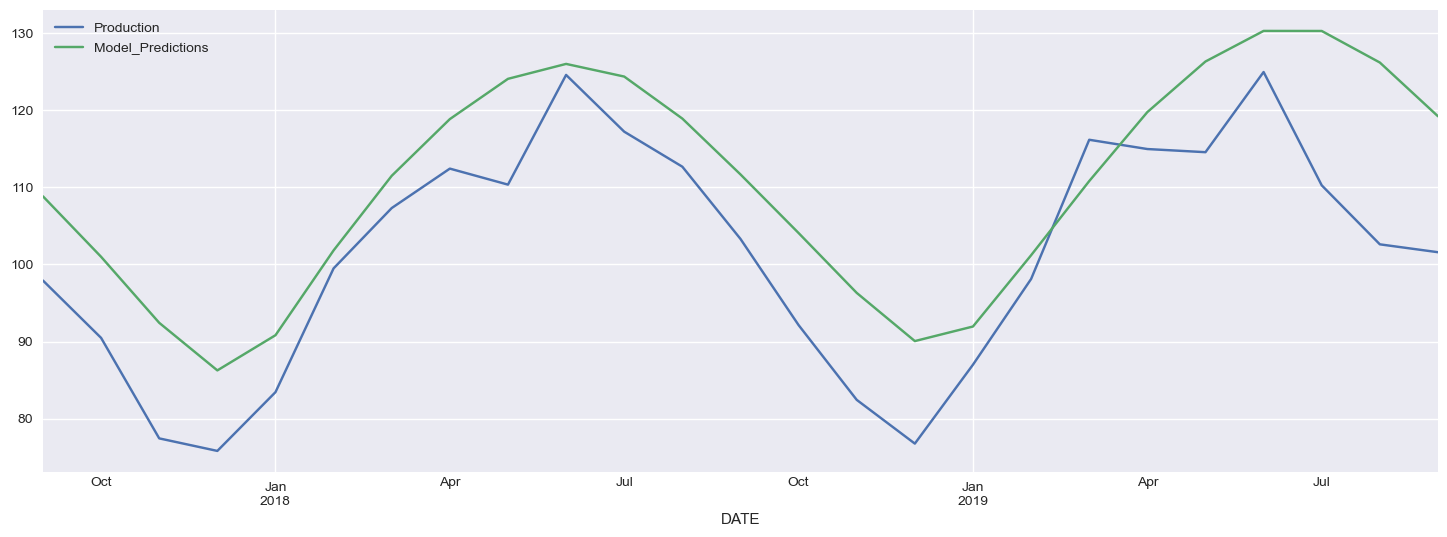

In [40]:
# CODE HERE
test.plot(figsize = (18,6))
plt.show()

**TASK: Calculate your RMSE.**

In [1]:
#CODE HERE

In [41]:
from statsmodels.tools.eval_measures import rmse

In [42]:
rmse(test["Production"], test["Model_Predictions"])

np.float64(11.072858588683486)